In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# --- 1. SPATIAL STRESS DATA GENERATORS ---
def create_canvas_dataset(images, canvas_size=56, random_shift=False):
    dataset = np.zeros((len(images), canvas_size, canvas_size))
    for i, img in enumerate(images):
        if random_shift:
            h_off = np.random.randint(0, canvas_size - 28 + 1)
            v_off = np.random.randint(0, canvas_size - 28 + 1)
        else:
            h_off, v_off = (canvas_size - 28) // 2, (canvas_size - 28) // 2
        dataset[i, v_off:v_off+28, h_off:h_off+28] = img
    return dataset

def apply_permutation(images_flat):
    np.random.seed(42) 
    perm_indices = np.random.permutation(images_flat.shape[1])
    return images_flat[:, perm_indices]

def apply_occlusion(images, patch_size=12):
    occluded = images.copy()
    canvas_size = images.shape[1]
    for img in occluded:
        x = np.random.randint(0, canvas_size - patch_size)
        y = np.random.randint(0, canvas_size - patch_size)
        img[y:y+patch_size, x:x+patch_size] = 0
    return occluded

# --- 2. DATA LOADERS ---
def get_training_data(sample_size=10000, canvas_size=56):
    (x_train, y_train), (_, _) = tf.keras.datasets.mnist.load_data()
    x_train, y_train = x_train[:sample_size] / 255.0, y_train[:sample_size]
    X_train_base = create_canvas_dataset(x_train, canvas_size, random_shift=False)
    return X_train_base, y_train, canvas_size

def get_testing_data(sample_size=10000, canvas_size=56):
    (_, _), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    x_test, y_test = x_test[:sample_size//5] / 255.0, y_test[:sample_size//5]
    
    X_test_base = create_canvas_dataset(x_test, canvas_size, random_shift=False)
    X_test_shifted = create_canvas_dataset(x_test, canvas_size, random_shift=True)
    X_test_permuted = apply_permutation(X_test_base.reshape(-1, canvas_size*canvas_size)).reshape(-1, canvas_size, canvas_size)
    X_test_occluded = apply_occlusion(X_test_base)
    
    test_conditions = {
        'Baseline': X_test_base,
        'Shifted': X_test_shifted,
        'Permuted': X_test_permuted,
        'Occluded': X_test_occluded
    }
    return test_conditions, y_test

In [2]:
def train_models_in_ram():
    X_train_base, y_train, canvas = get_training_data()
    flat_dim = canvas * canvas
    models_in_memory = {}
    
    # 1. Train CNN
    print("Training CNN...")
    cnn_model = Sequential([
        Conv2D(32, (3,3), padding='Same', activation='relu', input_shape=(canvas, canvas, 1)),
        MaxPool2D((2,2)),
        Conv2D(64, (3,3), padding='Same', activation='relu'),
        MaxPool2D((2,2)),
        Conv2D(128, (3,3), padding='Same', activation='relu'),
        GlobalAveragePooling2D(),
        Dense(10, activation="softmax")
    ])
    cnn_model.compile(optimizer='adam', loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    
    cnn_model.fit(X_train_base.reshape(-1, canvas, canvas, 1), y_train, 
                  epochs=15, validation_split=0.1, callbacks=[early_stop], verbose=1)
    
    models_in_memory['CNN'] = cnn_model

    # 2. Train GBDTs
    print("\nTraining GBDTs...")
    X_train_flat = X_train_base.reshape(-1, flat_dim)
    
    gbdts = {
        'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1),
        'LightGBM': lgb.LGBMClassifier(n_jobs=-1, verbose=-1),
        'CatBoost': CatBoostClassifier(verbose=0, thread_count=-1)
    }
    
    for name, model in gbdts.items():
        print(f"Training {name}...")
        model.fit(X_train_flat, y_train)
        models_in_memory[name] = model

    print("\nAll models successfully trained and stored in RAM.")
    return models_in_memory

# Execute and store the models in the notebook's global memory
trained_models_dict = train_models_in_ram()

Training CNN...
Epoch 1/15


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.3804 - loss: 1.7396 - val_accuracy: 0.6770 - val_loss: 1.0424
Epoch 2/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8169 - loss: 0.6629 - val_accuracy: 0.8740 - val_loss: 0.4316
Epoch 3/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8910 - loss: 0.3928 - val_accuracy: 0.9270 - val_loss: 0.2708
Epoch 4/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9108 - loss: 0.3102 - val_accuracy: 0.9140 - val_loss: 0.2690
Epoch 5/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9244 - loss: 0.2599 - val_accuracy: 0.9360 - val_loss: 0.2119
Epoch 6/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9343 - loss: 0.2313 - val_accuracy: 0.8990 - val_loss: 0.3156
Epoch 7/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9390 - loss: 0.2035 - val_accuracy: 0.9410 - val_loss: 0.1976
Epoch 8/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9471 - loss: 0.1809 - val_accuracy: 0.946

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [13:29:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training LightGBM...
Training CatBoost...

All models successfully trained and stored in RAM.


In [3]:
def evaluate_models_in_ram(models_dict):
    test_conds, y_test = get_testing_data()
    canvas = 56
    flat_dim = canvas * canvas
    results = {}

    print("Evaluating models across all spatial stress conditions...")

    for name, model in models_dict.items():
        results[name] = {}
        for cond_name, X_test in test_conds.items():
            if name == 'CNN':
                # CNN expects 4D tensors
                _, acc = model.evaluate(X_test.reshape(-1, canvas, canvas, 1), y_test, verbose=0)
            else:
                # GBDTs expect flattened 2D arrays
                acc = accuracy_score(y_test, model.predict(X_test.reshape(-1, flat_dim)))
            
            results[name][cond_name] = acc
            print(f"{name} -> {cond_name}: {acc*100:.2f}%")
            
    print("\nEvaluation complete! Results stored in RAM.")
    return results

# Execute and store the results dictionary in memory
evaluation_results_dict = evaluate_models_in_ram(trained_models_dict)

Evaluating models across all spatial stress conditions...
CNN -> Baseline: 95.25%
CNN -> Shifted: 95.50%
CNN -> Permuted: 10.85%
CNN -> Occluded: 86.95%
XGBoost -> Baseline: 93.35%
XGBoost -> Shifted: 13.55%
XGBoost -> Permuted: 11.85%
XGBoost -> Occluded: 87.80%
LightGBM -> Baseline: 94.45%
LightGBM -> Shifted: 14.05%
LightGBM -> Permuted: 10.60%
LightGBM -> Occluded: 88.35%
CatBoost -> Baseline: 93.10%
CatBoost -> Shifted: 15.60%
CatBoost -> Permuted: 12.20%
CatBoost -> Occluded: 86.85%

Evaluation complete! Results stored in RAM.


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


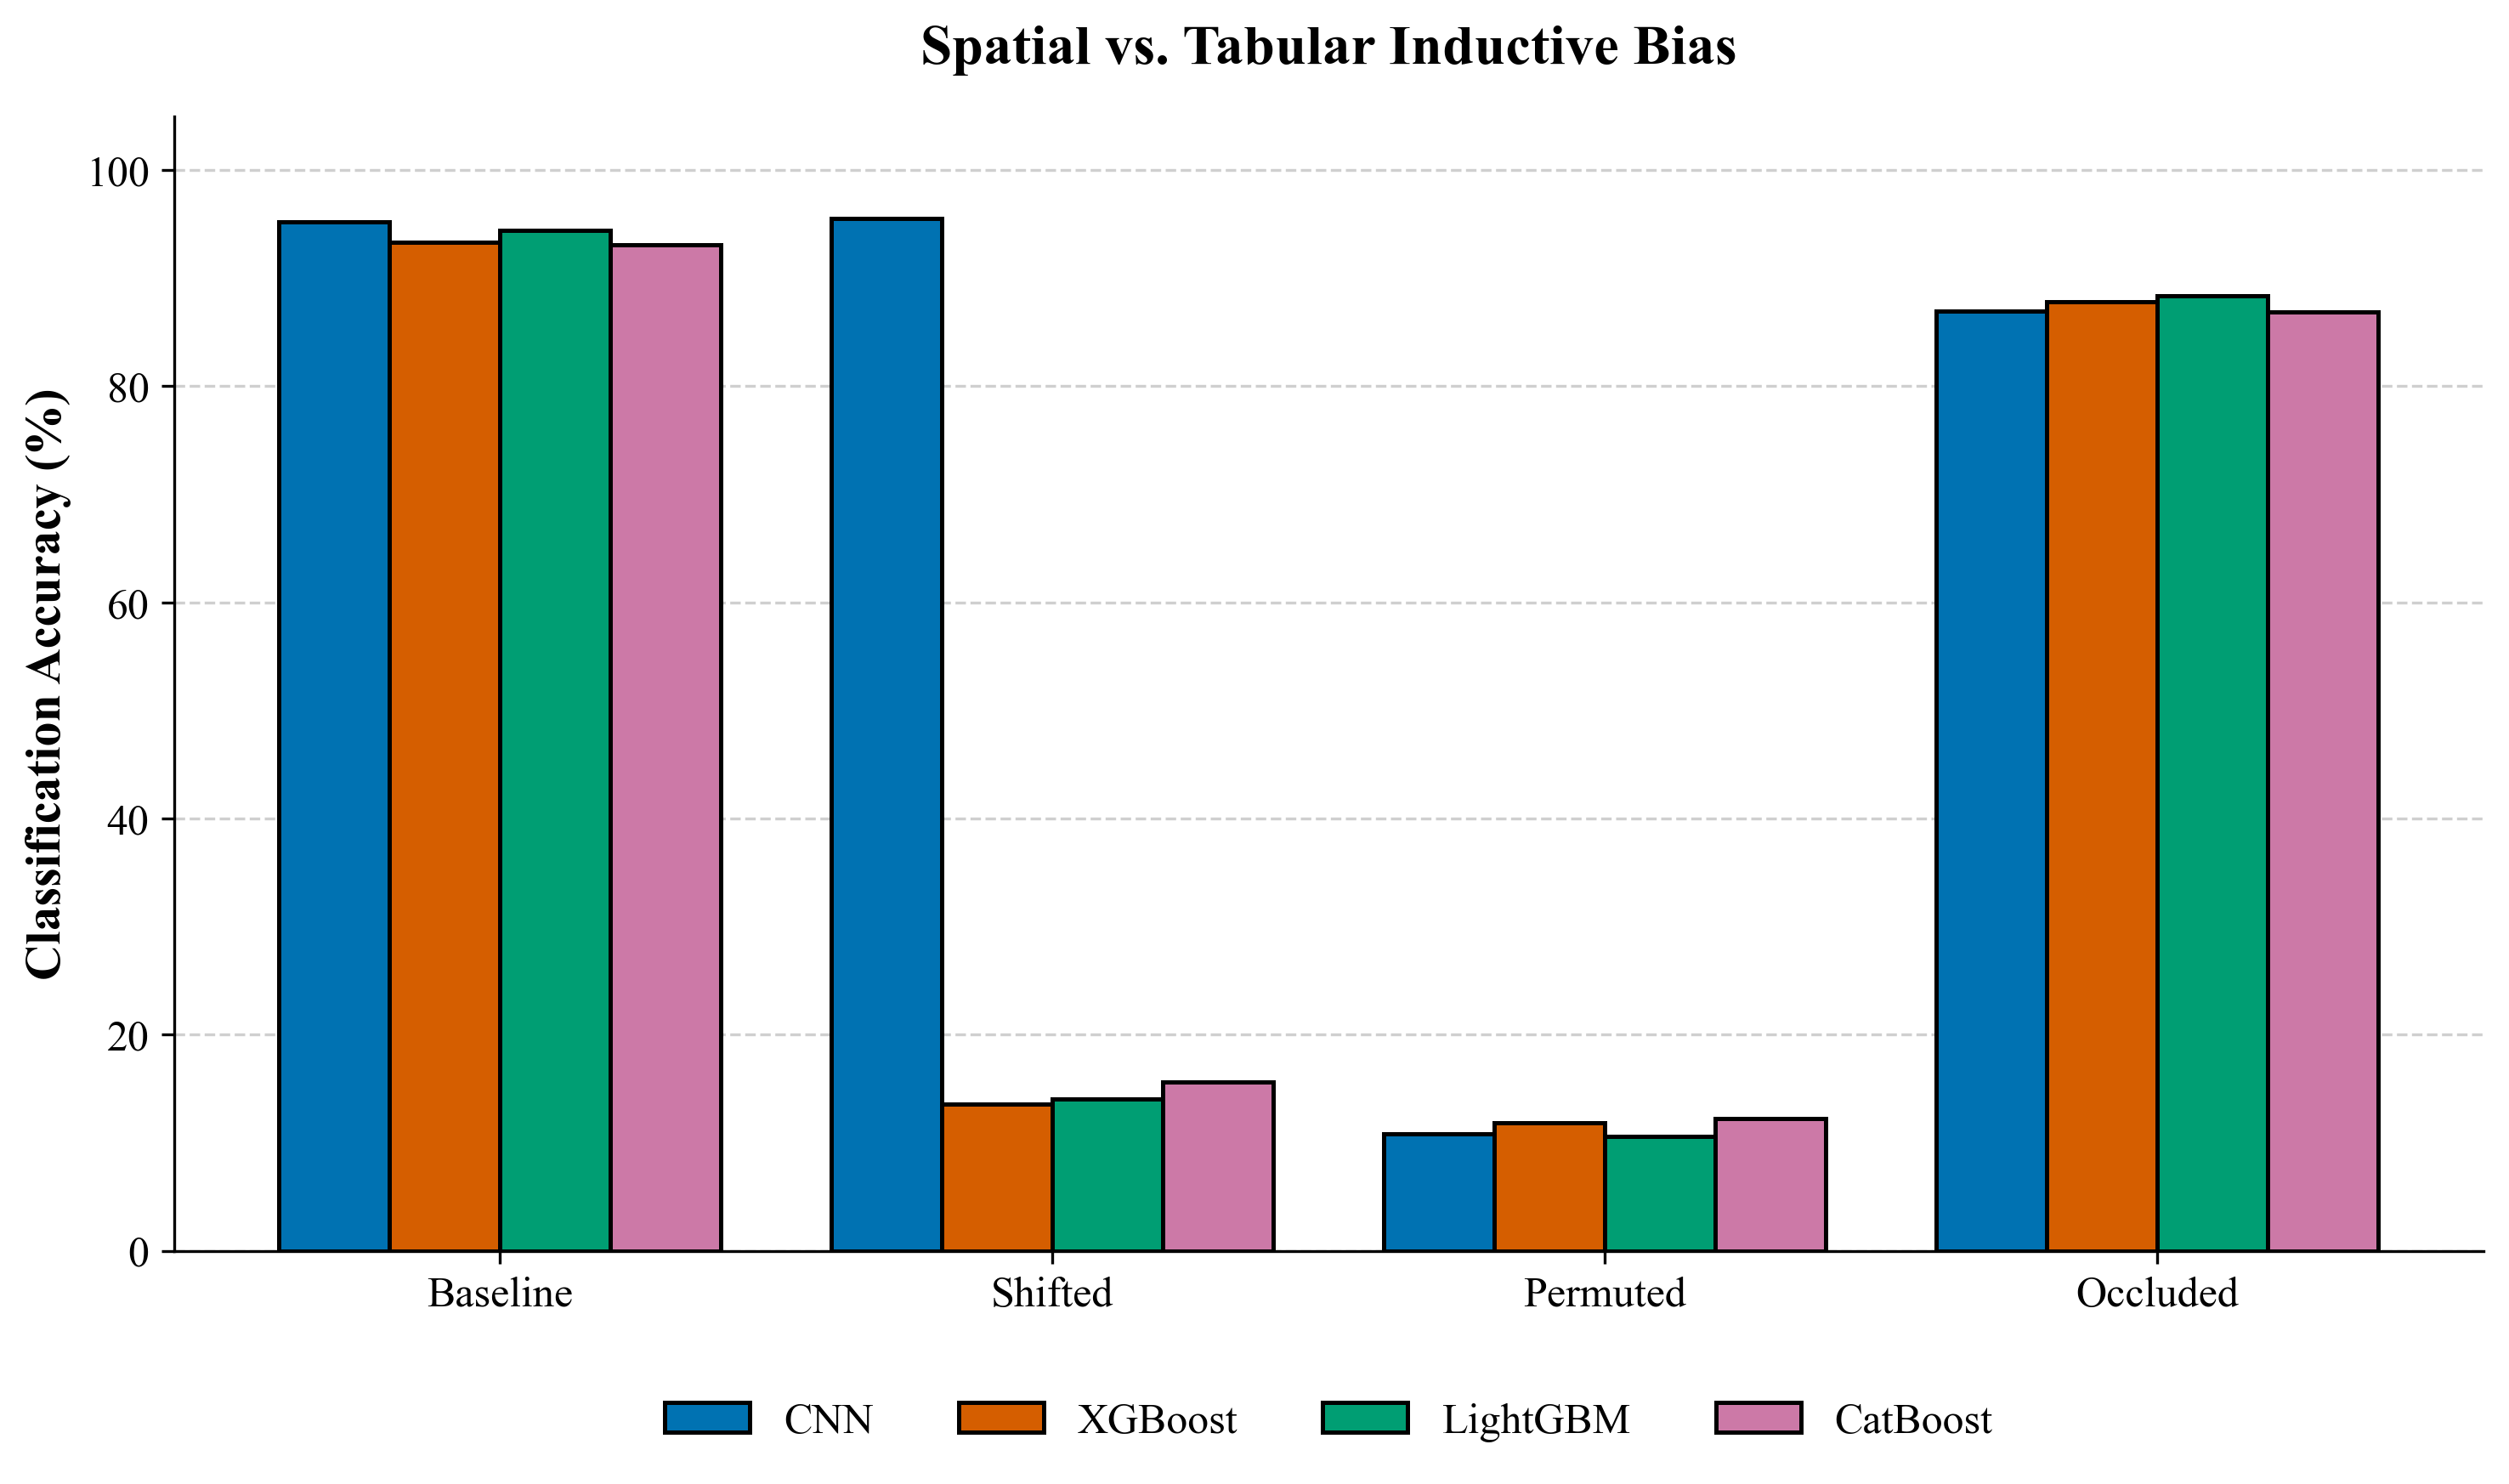

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def plot_results_publication_style(results):
    # 1. Update rcParams for academic typography and high-resolution rendering
    plt.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif'], # Standard academic fonts
        'font.size': 12,
        'axes.labelsize': 14,
        'axes.titlesize': 16,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'figure.dpi': 300,        # 300 DPI is required by most journals
        'savefig.dpi': 300,
        'savefig.bbox': 'tight'   # Prevents cutting off labels when saving
    })

    models = list(results.keys())
    conditions = list(results[models[0]].keys())
    
    x = np.arange(len(conditions))
    width = 0.2
    
    # Slightly tighter dimensions to fit perfectly in a two-column paper
    fig, ax = plt.subplots(figsize=(10, 6)) 
    
    # 2. Colorblind-safe, high-contrast academic palette (Okabe-Ito inspired)
    colors = ['#0072B2', '#D55E00', '#009E73', '#CC79A7'] 
    
    for i, model in enumerate(models):
        scores = [results[model][cond] * 100 for cond in conditions]
        
        # 3. Add edgecolors and zorder to make bars pop in print
        ax.bar(x + (i - 1.5) * width, scores, width, 
               label=model, color=colors[i], 
               edgecolor='black', linewidth=1.2, zorder=3)
        
    ax.set_ylabel('Classification Accuracy (%)', weight='bold')
    ax.set_title('Spatial vs. Tabular Inductive Bias', weight='bold', pad=15)
    
    ax.set_xticks(x)
    # Automatically clean up condition names for the labels
    ax.set_xticklabels([str(cond).replace('_', ' ') for cond in conditions])
    
    # 4. Remove Chart Junk (Edward Tufte's principles)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # 5. Place gridlines *behind* the bars
    ax.grid(axis='y', linestyle='--', alpha=0.6, zorder=0)
    
    ax.set_ylim(0, 105)
    
    # 6. Clean, frameless legend placed at the bottom to save vertical space
    ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)
    
    plt.tight_layout()
    plt.savefig('Phase_5_Inductive_Bias_Publication.pdf')
    plt.show()

# Re-run this cell instantly to view the publication-ready plot
plot_results_publication_style(evaluation_results_dict)

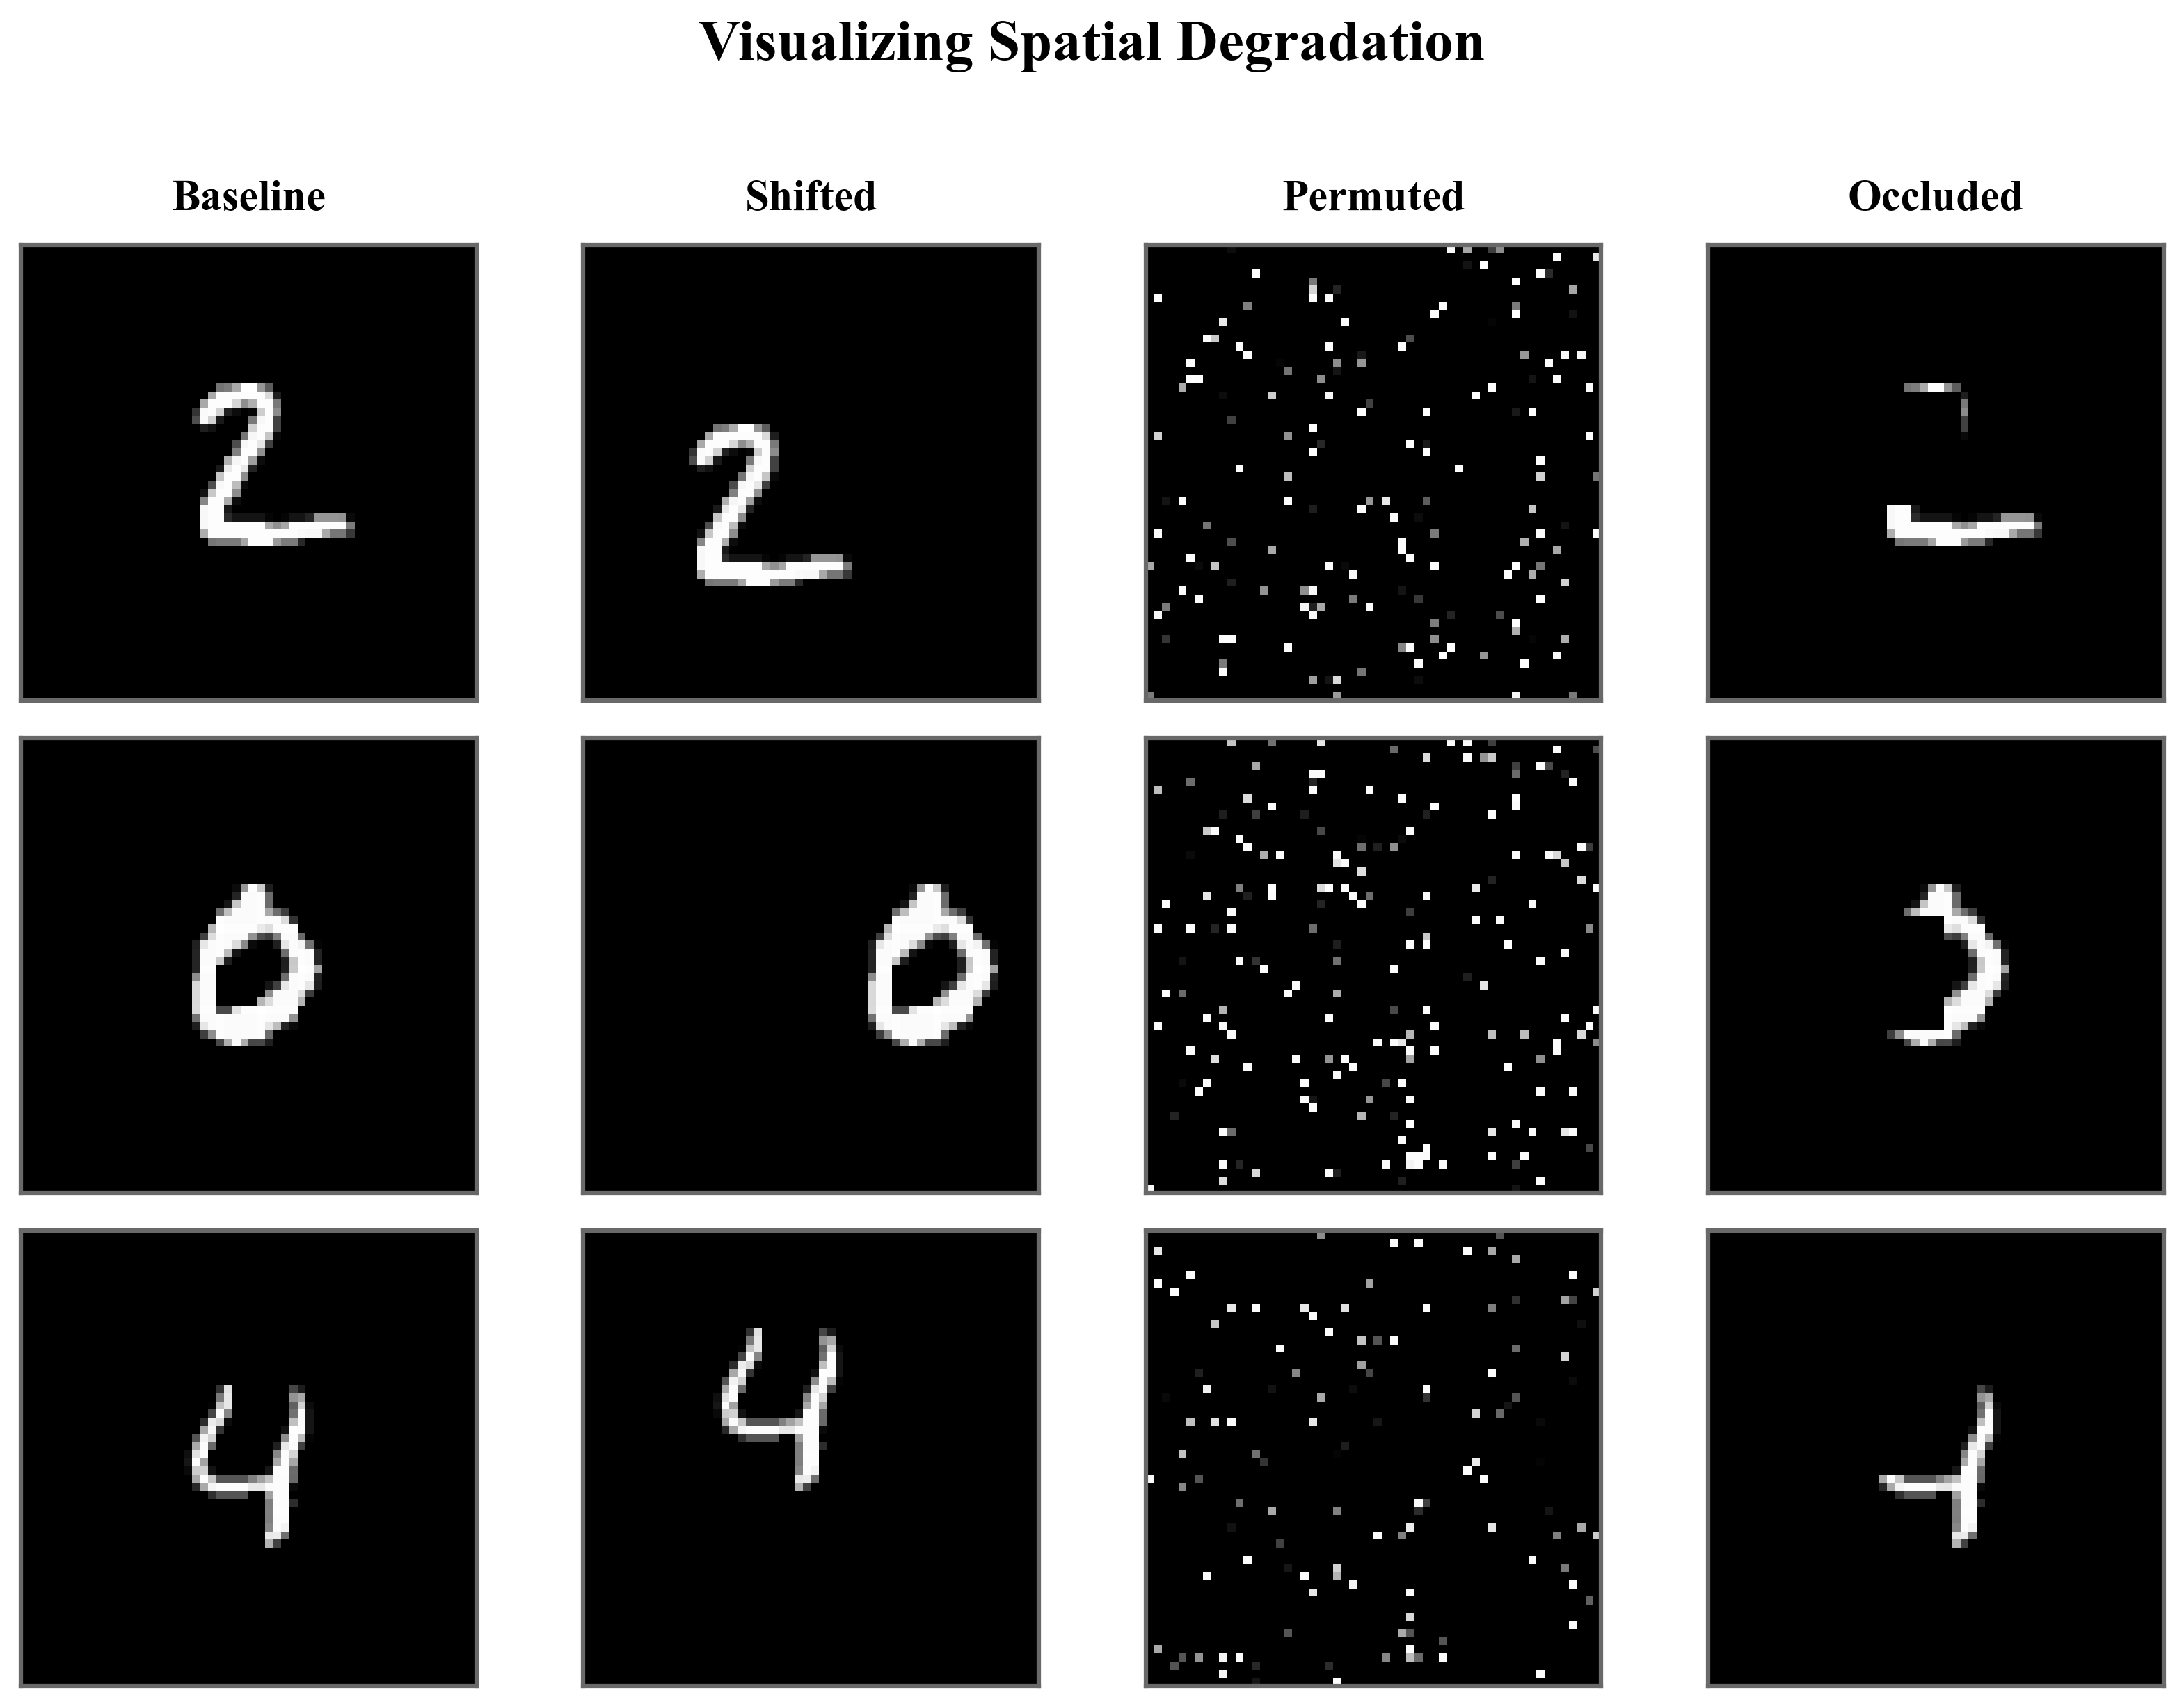

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# ==========================================
# 1. SPATIAL STRESS FUNCTIONS
# ==========================================
def create_canvas_dataset(images, canvas_size=56, random_shift=False):
    dataset = np.zeros((len(images), canvas_size, canvas_size))
    for i, img in enumerate(images):
        if random_shift:
            h_off = np.random.randint(0, canvas_size - 28 + 1)
            v_off = np.random.randint(0, canvas_size - 28 + 1)
        else:
            h_off, v_off = (canvas_size - 28) // 2, (canvas_size - 28) // 2
        dataset[i, v_off:v_off+28, h_off:h_off+28] = img
    return dataset

def apply_permutation(images_flat):
    np.random.seed(42)
    perm_indices = np.random.permutation(images_flat.shape[1])
    return images_flat[:, perm_indices]

# ==========================================
# 2. DATA PREPARATION
# ==========================================
# Load specific visually distinct samples from MNIST (e.g., 2, 0, 4)
(_, _), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# We pick specific indices from x_test that represent a 2, a 0, and a 4 for variety
sample_images = np.array([x_test[1], x_test[3], x_test[4]]) / 255.0 
canvas_size = 56

# A. Baseline
baseline = create_canvas_dataset(sample_images, canvas_size, random_shift=False)

# B. Shifted
np.random.seed(42) # Ensure reproducible random shifts
shifted = create_canvas_dataset(sample_images, canvas_size, random_shift=True)

# C. Permuted
permuted = apply_permutation(baseline.reshape(-1, canvas_size*canvas_size)).reshape(-1, canvas_size, canvas_size)

# D. Occluded
occluded = baseline.copy()
np.random.seed(24) # Ensure reproducible occlusion patches
patch_size = 14

for img in occluded:
    # Restrict random choice to the center so the black patch actually hits the digit
    x = np.random.randint(15, canvas_size - patch_size - 15)
    y = np.random.randint(15, canvas_size - patch_size - 15)
    img[y:y+patch_size, x:x+patch_size] = 0

# ==========================================
# 3. PUBLICATION-STYLE PLOTTING
# ==========================================
conditions = ['Baseline', 'Shifted', 'Permuted', 'Occluded']
data = [baseline, shifted, permuted, occluded]

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'], 
})

fig, axes = plt.subplots(3, 4, figsize=(11, 8))
for row in range(3):
    for col in range(4):
        ax = axes[row, col]
        ax.imshow(data[col][row], cmap='gray')
        
        # Add a subtle border to define the 56x56 canvas clearly
        for spine in ax.spines.values():
            spine.set_edgecolor('dimgray')
            spine.set_linewidth(1.5)
            
        ax.set_xticks([])
        ax.set_yticks([])
        
        # Column Titles on the top row
        if row == 0:
            ax.set_title(conditions[col], fontsize=15, fontweight='bold', pad=12)

plt.suptitle("Visualizing Spatial Degradation", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()

# Save as vector PDF for pristine quality in your LaTeX or Word doc
plt.savefig("spatial_stress_visualization.pdf", bbox_inches='tight', dpi=300)
plt.show()